<a href="https://colab.research.google.com/github/paulstoy/FluxTowers/blob/main/TowerEnvironment_IJBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TowerEnvironment.ipynb

Use this file to perform analyses and create all figures except for the soil texture triangle (written in R) for 'The spatial and environmental distribution of the global eddy covariance tower network' in the <i>International Journal of Biometeorology</i>.

First, load libraries, and import data from [github](https://github.com/paulstoy/FluxTowers), noting the [ReadMe](https://github.com/paulstoy/FluxTowers/blob/main/README.md) file. Data are also avaible on Zenodo in the repository that contains this file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import geopandas as gpd
import seaborn as sns

a = pd.read_csv('https://raw.githubusercontent.com/paulstoy/FluxTowers/main/Towers.csv')
r = pd.read_csv('https://raw.githubusercontent.com/paulstoy/FluxTowers/main/RandomPoints.csv')
rdepth = pd.read_csv('https://raw.githubusercontent.com/paulstoy/FluxTowers/main/RandomSoilDepth.csv',header=None)
tdepth = pd.read_csv('https://raw.githubusercontent.com/paulstoy/FluxTowers/main/TowerSoilDepth.csv')

Quantify the distance between all towers. This takes awhile, 'distm' from the 'geosphere' package in R is much faster. For efficiency, the output from this chunk is available on github, and can be loaded by skipping this chunk and running the chunk below.

In [ ]:
import geopy.distance

R,C=a.shape

m = np.empty((R,R))

for i in range(0,R):
  print(i)
  for j in range(0,R):
    m[i,j] = geopy.distance.geodesic((a.Lat[i], a.Long[i]),(a.Lat[j], a.Long[j])).km

#trick python into thinking the eigenvalues are impossibly large
m[m==0] = 1e10

#calculate the minimum distance to another tower for each tower site
x = np.min(m,axis=0)

#create a pandas dataframe with rows and columns labeled
m_pd = pd.DataFrame(m, columns=a["Site ID"], index=a["Site ID"])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

Alternately, load the distance matrix directly from github as .csv and extract the list of shortest distances, 'x'.

In [2]:
m_pd = pd.read_csv('https://raw.githubusercontent.com/paulstoy/FluxTowers/main/DistanceMatrix.csv')
mtemp = m_pd
del mtemp['Site ID']
m = np.array(mtemp)
del mtemp
m[m==0] = 1e10
x = np.min(m_pd,axis=0)

#Figure 1:
A map of tower locations, colored by distance to nearest tower

First, install geopandas and download the naturalearth_lowres dataset from Amazon AWS.

In [3]:
!pip install geopandas

import geopandas as gpd
import matplotlib.pyplot as plt

# Download the naturalearth_lowres data
!wget https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip
!unzip ne_110m_admin_0_countries.zip

# Read the shapefile into GeoPandas
countries = gpd.read_file("ne_110m_admin_0_countries.shp")

--2026-03-06 17:52:09--  https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip
Resolving naturalearth.s3.amazonaws.com (naturalearth.s3.amazonaws.com)... 52.92.211.137, 52.92.177.73, 3.5.78.194, ...
Connecting to naturalearth.s3.amazonaws.com (naturalearth.s3.amazonaws.com)|52.92.211.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 214976 (210K) [application/zip]
Saving to: ‘ne_110m_admin_0_countries.zip.2’

ne_110m_admin_0_cou 100%[===================>] 209.94K  --.-KB/s    in 0.1s    

2026-03-06 17:52:10 (1.46 MB/s) - ‘ne_110m_admin_0_countries.zip.2’ saved [214976/214976]

Archive:  ne_110m_admin_0_countries.zip
replace ne_110m_admin_0_countries.README.html? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ne_110m_admin_0_countries.VERSION.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ne_110m_admin_0_countries.cpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ne_110m_admin_0_countries.dbf? [y]es, [n]o, [A]ll, [N]one,

Create the plot by adding tower locations to the map.

/tmp/ipykernel_44931/1178107736.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["km"] = x.tolist()


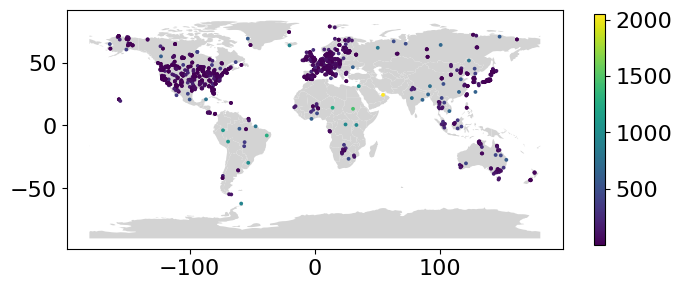

In [4]:
d = a[["Lat", "Long"]]
#d["Dist (km)"] = np.log(x).tolist()
d["km"] = x.tolist()

fig, ax = plt.subplots(figsize=(8,6)) # define fig, ax before plotting

countries.plot(color="lightgrey",ax=ax) # Use the loaded countries GeoDataFrame
points = ax.scatter(x=d["Long"], y=d["Lat"], s=3, c=d["km"], cmap="viridis") # create scatter plot and assign it to points
plt.colorbar(points, shrink=0.5, ax=ax)  # Pass the scatter plot object to colorbar and specify the axes

plt.xlabel("")  # Set x-axis label to empty
plt.ylabel("")  # Set y-axis label to empty

plt.show() # to display the plot

#Figure 2:
a plot of tower temperature and precipitation against a kernel density estimate of global temperature and precipitation

<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_44931/482491491.py:8: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("MAT ($^\circ$C)")


Text(0, 0.5, 'MAP (mm)')

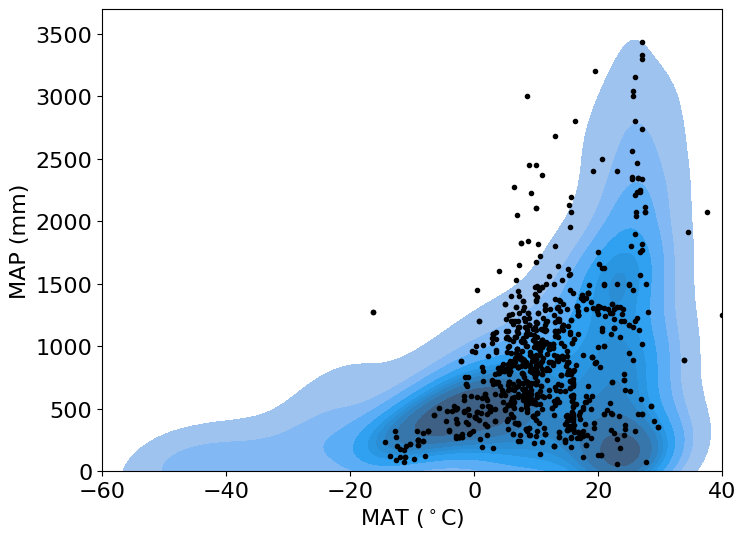

In [5]:
PTglobal = r[["MAT_ds", "MAP_ds"]]

fig, ax = plt.subplots(figsize=(8,6))
sns.kdeplot(data=PTglobal, x="MAT_ds", y="MAP_ds", fill=True,ax=ax)
plt.plot(a.MAT,a.MAP,'.',color='k')
plt.xlim([-60,40])
plt.ylim([0,3700])
plt.xlabel("MAT ($^\circ$C)")
plt.ylabel("MAP (mm)")

#Figure 3:
The distribution of climate and elevation from global terrestrial databases compared to dataset pixels that contain eddy covariance towers.

<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_44931/1794541920.py:4: SyntaxWarning: invalid escape sequence '\c'
  axs[0].set(xlabel="MAT ($^\circ$C)", ylabel="Density",xlim=([-30,40]))
/tmp/ipykernel_44931/1794541920.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elevation_temp[np.isnan(r.MAT_ds)==1] = np.nan


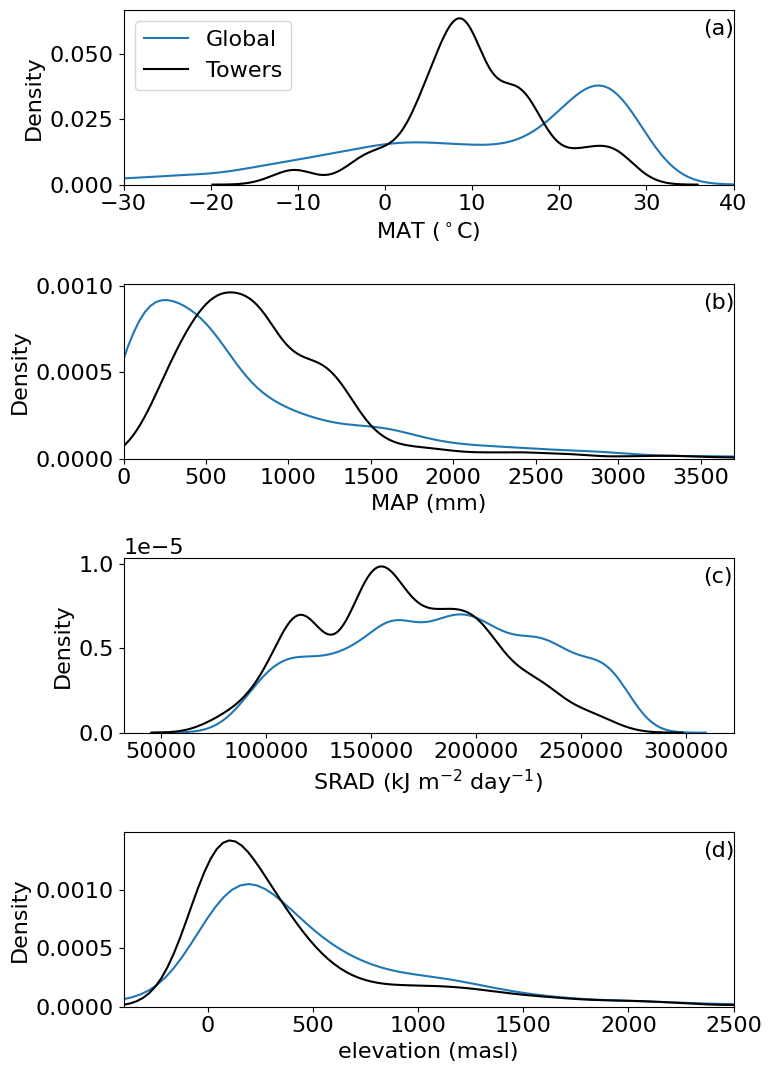

In [6]:
fig, axs = plt.subplots(4,1,figsize=(8,11))
sns.kdeplot(ax=axs[0],data=r,x='MAT_ds',label='Global')
sns.kdeplot(ax=axs[0],data=a,x='MAT_ds',color='k',label='Towers')
axs[0].set(xlabel="MAT ($^\circ$C)", ylabel="Density",xlim=([-30,40]))
axs[0].legend()
axs[0].text(0.95,0.95,"(a)",transform=axs[0].transAxes, ha='left', va='top')

sns.kdeplot(ax=axs[1],data=r,x='MAP_ds')
sns.kdeplot(ax=axs[1],data=a,x='MAP_ds',color='k')
axs[1].set(xlabel="MAP (mm)", ylabel="Density",xlim=([0,3700]))
axs[1].text(0.95,0.95,"(b)",transform=axs[1].transAxes, ha='left', va='top')

sns.kdeplot(ax=axs[2],data=r,x='SRAD_ds')
sns.kdeplot(ax=axs[2],data=a,x='SRAD_ds',color='k')
axs[2].set(xlabel="SRAD (kJ m$^{-2}$ day$^{-1}$)", ylabel="Density")
axs[2].text(0.95,0.95,"(c)",transform=axs[2].transAxes, ha='left', va='top')

elevation_temp = r.Elevation_ds
elevation_temp[np.isnan(r.MAT_ds)==1] = np.nan
sns.kdeplot(ax=axs[3],x=elevation_temp)
sns.kdeplot(ax=axs[3],data=a,x='Elevation_ds',color='k')
axs[3].set(xlabel="elevation (masl)", ylabel="Density",xlim=([-400,2500]))
axs[3].text(0.95,0.95,"(d)",transform=axs[3].transAxes, ha='left', va='top')

fig.tight_layout()

#Figure 4:
This is a plot of soil texture triangles that was created in R.

#Figure 5:
Probability density functions of sand (a), silt (b), and clay (c) fractions for a random sample of 10,000 points on the terrestrial surface from SoilGrids 2.0 (Poggio et al. 2021) (‘Global’) and eddy covariance tower locations (‘Towers’)

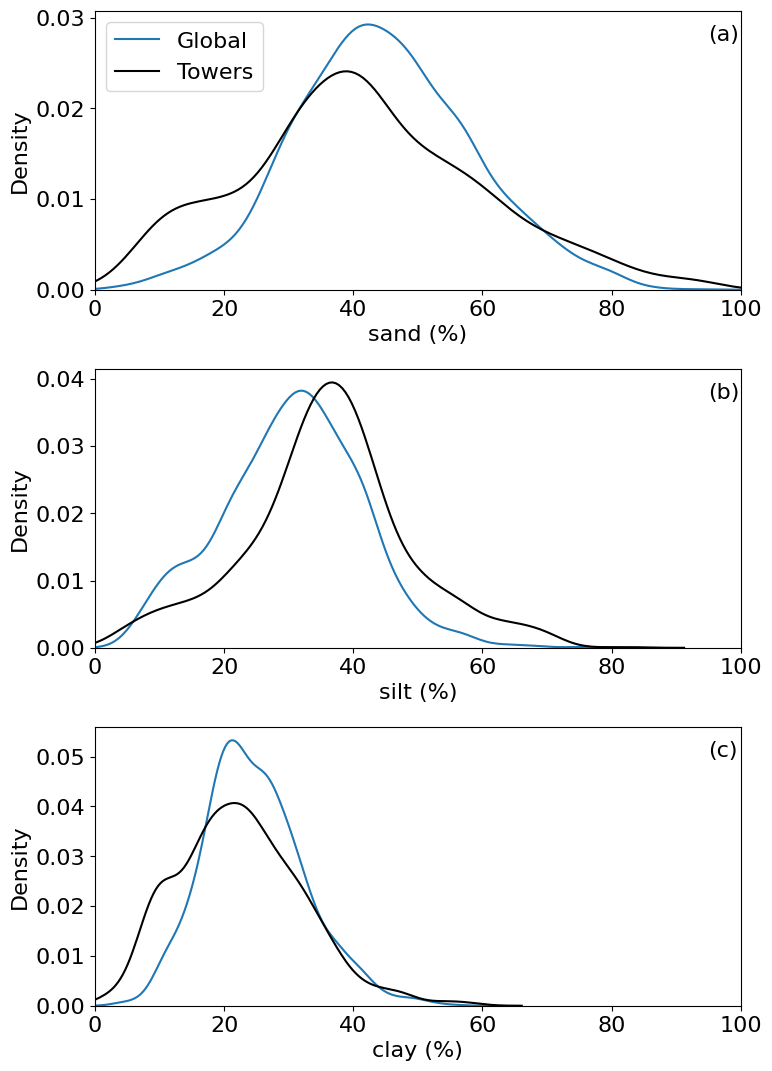

In [7]:
fig, axs = plt.subplots(3,1,figsize=(8,11))
sns.kdeplot(ax=axs[0],data=r,x='sand',label='Global')
sns.kdeplot(ax=axs[0],data=a,x='sand',color='k',label='Towers')
axs[0].legend()
axs[0].set(xlabel="sand (%)", ylabel="Density",xlim=([0,100]))
axs[0].text(0.95,0.95,"(a)",transform=axs[0].transAxes, ha='left', va='top')

sns.kdeplot(ax=axs[1],data=r,x='silt')
sns.kdeplot(ax=axs[1],data=a,x='silt',color='k')
axs[1].set(xlabel="silt (%)", ylabel="Density",xlim=([0,100]))
axs[1].text(0.95,0.95,"(b)",transform=axs[1].transAxes, ha='left', va='top')

sns.kdeplot(ax=axs[2],data=r,x='clay')
sns.kdeplot(ax=axs[2],data=a,x='clay',color='k')
axs[2].set(xlabel="clay (%)", ylabel="Density",xlim=([0,100]))
axs[2].text(0.95,0.95,"(c)",transform=axs[2].transAxes, ha='left', va='top')

fig.tight_layout()

#Figure 6:
Probability density functions of soil N (a), soil organic carbon (soc, b), cation exchange capacity (cec, c), and pH (d) for a random sample of 10,000 points on the terrestrial surface from SoilGrids2.0 (Poggio et al. 2021) (‘Global’) and eddy covariance tower locations (‘Towers’)

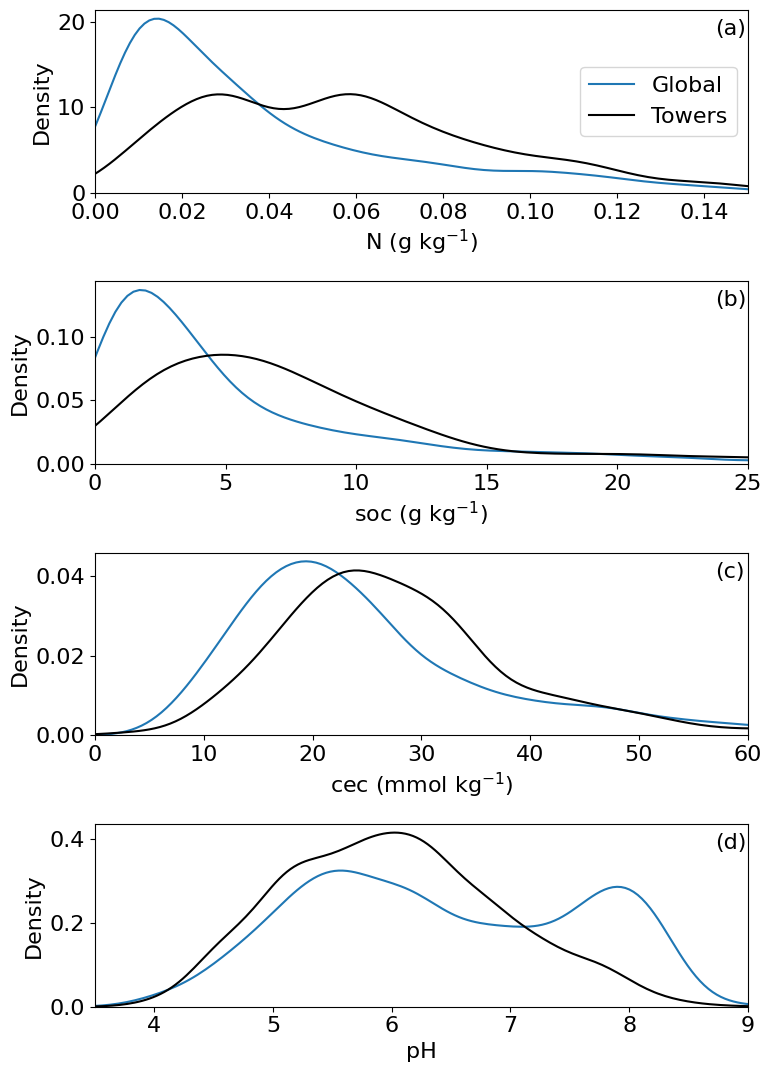

In [13]:
fig, axs = plt.subplots(4,1,figsize=(8,11))
sns.kdeplot(ax=axs[0],data=r,x='N',label='Global')
sns.kdeplot(ax=axs[0],data=a,x='N',color='k',label='Towers')
axs[0].set(xlabel="N (g kg$^{-1}$)", ylabel="Density",xlim=([0,0.15]))
axs[0].text(0.95,0.95,"(a)",transform=axs[0].transAxes, ha='left', va='top')
axs[0].legend()
sns.kdeplot(ax=axs[1],data=r,x='soc')
sns.kdeplot(ax=axs[1],data=a,x='soc',color='k')
axs[1].set(xlabel="soc (g kg$^{-1}$)", ylabel="Density",xlim=([0,25]))
axs[1].text(0.95,0.95,"(b)",transform=axs[1].transAxes, ha='left', va='top')

sns.kdeplot(ax=axs[2],data=r,x='cec')
sns.kdeplot(ax=axs[2],data=a,x='cec',color='k')
axs[2].set(xlabel="cec (mmol kg$^{-1}$)", ylabel="Density",xlim=([0,60]))
axs[2].text(0.95,0.95,"(c)",transform=axs[2].transAxes, ha='left', va='top')

sns.kdeplot(ax=axs[3],data=r,x='pH')
sns.kdeplot(ax=axs[3],data=a,x='pH',color='k')
axs[3].set(xlabel="pH", ylabel="Density",xlim=([3.5,9]))
axs[3].text(0.95,0.95,"(d)",transform=axs[3].transAxes, ha='left', va='top')

fig.tight_layout()

##Figure 7:
The probability of soil and sedimentary deposit thickness for a random sample of 10,000 pixels, and pixels containing eddy covariance towers, from the database of Pelletier et al. (2016)


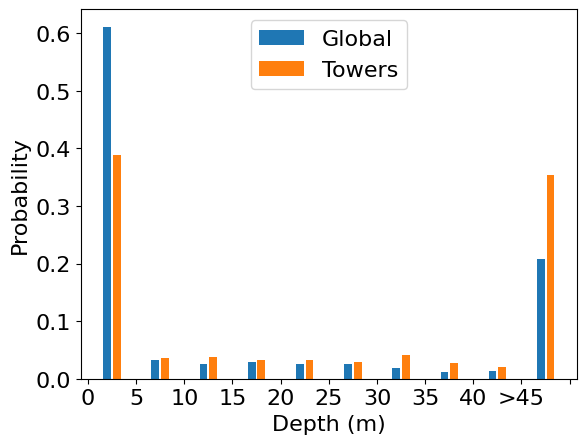

In [12]:
rplot = rdepth.to_numpy()
tplot = tdepth.depth.to_numpy()

rplot = rplot[rplot!=255]
tplot = tplot[tplot!=255]
tplot = tplot[np.isnan(tplot)==0]

h = np.histogram(rplot)
h0,h1=h

t = np.histogram(tplot)
t0,t1=t

plt.bar(h1[0:10]+2,h[0]/sum(h[0]),label='Global')
plt.bar(t1[0:10]+3,t[0]/sum(t[0]),label='Towers')
plt.xlabel("Depth (m)")
plt.ylabel("Probability")
plt.legend(loc='upper center')
plt.xticks([0,5,10,15,20,25,30,35,40,45,50], ['0','5','10','15','20','25','30','35','40','>45','']);

#axs[-1, -1].axis('off')

#Figure S1:
The cumulative percentage of ranked distances between towers

[625. 626.]
[1063.]


Text(0.5, 0, 'Percentage of sites')

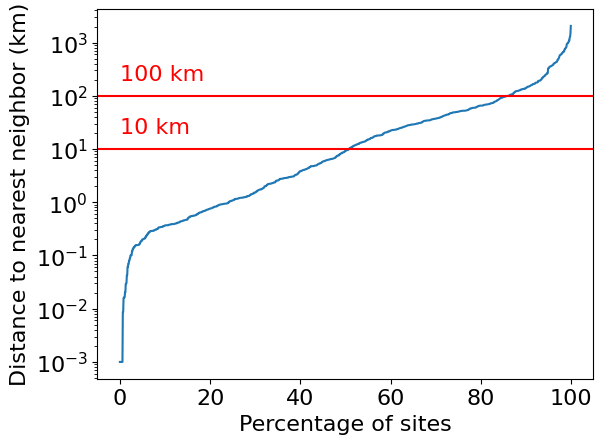

In [14]:
x[x < 1e-3] = 1e-3 #set sites with < 1 m distance to 1 m; co-located towers would be difficult to position < 1 m apart due to flow distortion
xax = np.arange(0,len(x))/len(x)*100
sortx = np.sort(x)
print(xax[(sortx>9.9) & (sortx < 10.1)]*1233/100)
print(xax[(sortx>99.9) & (sortx < 100.1)]*1233/100)

plt.semilogy(xax,np.sort(x))
plt.axhline(10,xmin=0, xmax=100,color='r')
plt.axhline(100,xmin=0, xmax=100,color='r')
plt.text(0,20,'10 km',color='r')
plt.text(0,200,'100 km',color='r')
plt.ylabel('Distance to nearest neighbor (km)')
plt.xlabel('Percentage of sites')


#Analysis: Welch's t-tests for differences between tower locations and global climate, elevation, and soil samples.

In [11]:
from scipy import stats

alpha = .05/13 #Bonferroni correction
print('alpha:', alpha)

t_stat, p_MAT = stats.ttest_ind(r.dropna()['MAT_ds'], a.dropna()['MAT_ds'])
print('MAT:', p_MAT)

t_stat, p_MAP = stats.ttest_ind(r.dropna()['MAP_ds'], a.dropna()['MAP_ds'])
print('MAP:', p_MAP)

t_stat, p_srad = stats.ttest_ind(r.dropna()['SRAD_ds'], a.dropna()['SRAD_ds'])
print('SRAD:', p_srad)

t_stat, p_elev = stats.ttest_ind(r.dropna()['Elevation_ds'], a.dropna()['Elevation_ds'])
print('elevation:', p_elev)

t_stat, p_clay = stats.ttest_ind(r.dropna()['clay'], a.dropna()['clay'])
print('clay:', p_clay)

t_stat, p_sand = stats.ttest_ind(r.dropna()['sand'], a.dropna()['sand'])
print('sand:', p_sand)

t_stat, p_silt = stats.ttest_ind(r.dropna()['silt'], a.dropna()['silt'])
print('silt:', p_silt)

t_stat, p_bdod = stats.ttest_ind(r.dropna()['bdod'], a.dropna()['bdod'])
print('bdod:', p_bdod)

t_stat, p_cec = stats.ttest_ind(r.dropna()['cec'], a.dropna()['cec'])
print('cec:', p_cec)

t_stat, p_pH = stats.ttest_ind(r.dropna()['pH'], a.dropna()['pH'])
print('pH:', p_pH)

t_stat, p_N = stats.ttest_ind(r.dropna()['N'], a.dropna()['N'])
print('N:', p_N)

t_stat, p_soc = stats.ttest_ind(r.dropna()['soc'], a.dropna()['soc'])
print('soc:', p_soc)


print(np.mean(r.dropna()['bdod']), np.std(r.dropna()['bdod']))
print(np.mean(a.dropna()['bdod']), np.std(a.dropna()['bdod']))


alpha: 0.0038461538461538464
MAT: 4.260127871813577e-10
MAP: 2.098472685530701e-05
SRAD: 8.317254716492318e-14
elevation: 3.1249001190239725e-05
clay: 5.968969506804131e-05
sand: 1.397227394149988e-16
silt: 9.61018367463897e-44
bdod: 0.6700940747651407
cec: 0.00023131473175612256
pH: 1.0599068652130008e-18
N: 1.6708988063885365e-27
soc: 5.581630356369087e-15
0.011762997562956946 0.002615062837987416
0.01181421143847487 0.002523931716703074
